In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [7]:
def plot_original_graph(distances):
    """Grafica la red completa con los pesos de las aristas."""
    G = nx.from_numpy_array(distances)
    pos = nx.spring_layout(G, seed=42)  # Layout fijo para consistencia
    
    plt.figure(figsize=(10, 7))
    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    # Dibujar etiquetas de nodos
    nx.draw_networkx_labels(G, pos)
    # Dibujar aristas con transparencia (para no saturar si son muchos nodos)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    
    # Dibujar pesos (solo si no son demasiados nodos para que sea legible)
    if len(distances) <= 10:
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    
    plt.title("1) Gráfica Original (Todas las conexiones)")
    plt.show()
    return pos # Retornamos la posición para usarla en la siguiente función

def plot_solution_path(distances, path, pos):
    """Grafica la solución encontrada resaltando el camino sobre la gráfica original."""
    G = nx.from_numpy_array(distances)
    
    # Creamos una lista de tuplas para las aristas del camino solución
    solution_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    plt.figure(figsize=(10, 7))
    # Dibujamos todos los nodos
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    nx.draw_networkx_labels(G, pos)
    
    # Dibujamos todas las aristas muy tenues
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
    
    # Resaltamos el camino de la solución en rojo y más grueso
    nx.draw_networkx_edges(G, pos, edgelist=solution_edges, 
                           edge_color='red', width=2.5, arrowstyle='->', arrowsize=20)
    
    plt.title(f"2) Solución ACO (Distancia: {best_distance:.2f})")
    plt.show()



In [8]:
class Graph:
    def __init__(self, distances):
        self.distances = distances
        self.num_nodes = len(distances)
        self.pheromones = np.ones_like(distances, dtype=float)

In [9]:
class Ant:
    def __init__(self, graph):
        self.graph = graph
        self.current_node = np.random.randint(graph.num_nodes)
        self.path = [self.current_node]
        self.total_distance = 0
        self.unvisited_nodes = set(range(graph.num_nodes)) - {self.current_node}

    def select_next_node(self):
        probabilities = np.zeros(self.graph.num_nodes)
        for node in self.unvisited_nodes:
            if self.graph.distances[self.current_node][node] > 0:
                # Probabilidad basada en feromonas y cercanía (1/distancia)
                probabilities[node] = (self.graph.pheromones[self.current_node][node] ** 2 /
                                       self.graph.distances[self.current_node][node])
        
        sum_probs = probabilities.sum()
        if sum_probs == 0: # Manejo de errores en caso de nodos aislados
            return np.random.choice(list(self.unvisited_nodes))
            
        probabilities /= sum_probs
        return np.random.choice(range(self.graph.num_nodes), p=probabilities)

    def move(self):
        next_node = self.select_next_node()
        self.path.append(next_node)
        self.total_distance += self.graph.distances[self.current_node][next_node]
        self.current_node = next_node
        self.unvisited_nodes.remove(next_node)

    def complete_path(self):
        while self.unvisited_nodes:
            self.move()
        # Regreso al nodo inicial para cerrar el ciclo
        self.total_distance += self.graph.distances[self.current_node][self.path[0]]
        self.path.append(self.path[0])

In [10]:
class ACO:
    def __init__(self, graph, num_ants, num_iterations, decay=0.5, alpha=1.0):
        self.graph = graph
        self.num_ants = num_ants
        self.num_iterations = num_iterations
        self.decay = decay
        self.alpha = alpha
        self.best_distance_history = []

    def run(self):
        best_path = None
        best_distance = np.inf
        for _ in range(self.num_iterations):
            ants = [Ant(self.graph) for _ in range(self.num_ants)]
            for ant in ants:
                ant.complete_path()
                if ant.total_distance < best_distance:
                    best_path = ant.path
                    best_distance = ant.total_distance
            self.update_pheromones(ants)
            self.best_distance_history.append(best_distance)
        return best_path, best_distance

    def update_pheromones(self, ants):
        self.graph.pheromones *= self.decay
        for ant in ants:
            for i in range(len(ant.path) - 1):
                from_node = ant.path[i]
                to_node = ant.path[i + 1]
                self.graph.pheromones[from_node][to_node] += self.alpha / ant.total_distance

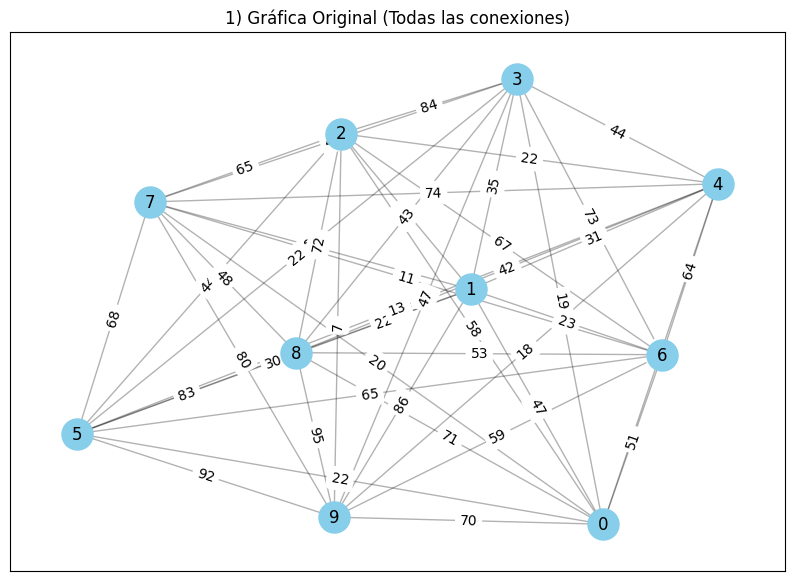

In [11]:
# num_nodes = 10 # Reducido a 10 para mejor visualización de etiquetas
distances = np.random.randint(1, 100, size=(num_nodes, num_nodes))
np.fill_diagonal(distances, 0)

# Llamada a las nuevas funciones
posiciones = plot_original_graph(distances)

/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_73805/403381070.py:39: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=solution_edges,
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_73805/403381070.py:39: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=solution_edges,


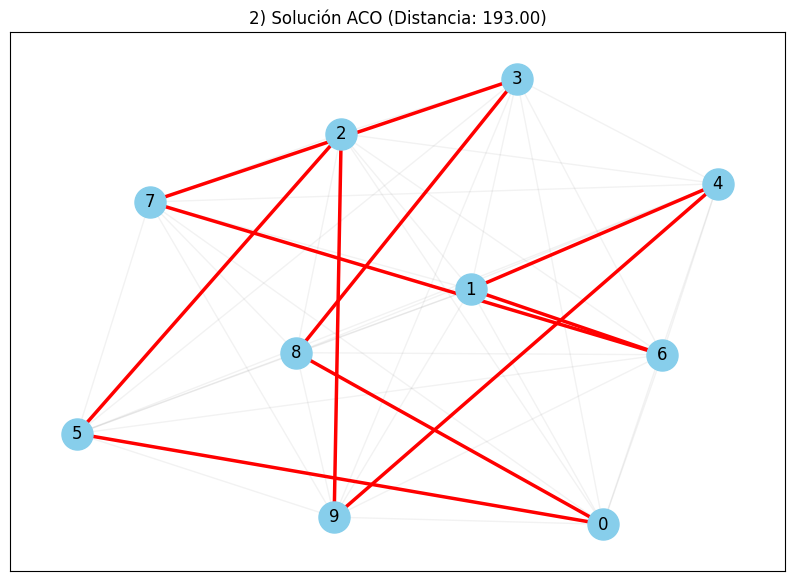

In [12]:
graph = Graph(distances)
aco = ACO(graph, num_ants=15, num_iterations=50)
best_path, best_distance = aco.run()

plot_solution_path(distances, best_path, posiciones)

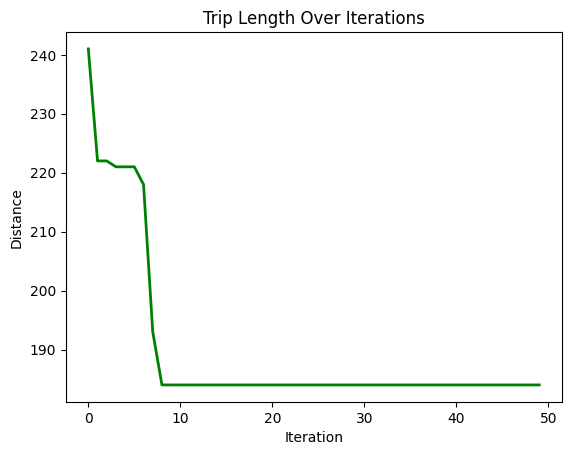

In [10]:
# Plotting the distance over iterations (second plot) - Shows how the path length improves over time
def plot_distance_over_iterations(best_distance_history):
    # Plot the best distance found in each iteration (should decrease over time)
    plt.plot(best_distance_history, color='green', linewidth=2)
    plt.title("Trip Length Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Distance")
    plt.show()

plot_distance_over_iterations(aco.best_distance_history)